In [11]:
!pip install --quiet matplotlib seaborn wordcloud scikit-learn joblib


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

sns.set(style="whitegrid")


In [13]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_email_dataset.csv to synthetic_email_dataset (1).csv


In [14]:
df = pd.read_csv("synthetic_email_dataset.csv")
print("Dataset loaded successfully!")
print(df.head())


Dataset loaded successfully!
                                                text  label
0  Congratulations! You won a free lottery of the...      1
1  Congratulations! You won a free lottery of all...      1
2  Congratulations! You won a free lottery of the...      1
3  Congratulations! You won a free lottery of any...      1
4  Congratulations! You won a free lottery of $3,...      1


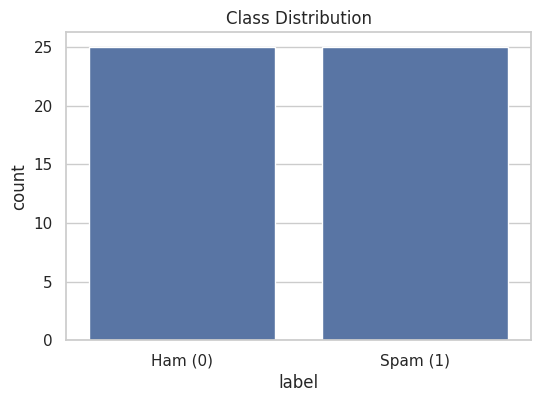

label
1    25
0    25
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.xticks([0,1], ['Ham (0)', 'Spam (1)'])
plt.title("Class Distribution")
plt.show()

# Print counts
print(df['label'].value_counts())


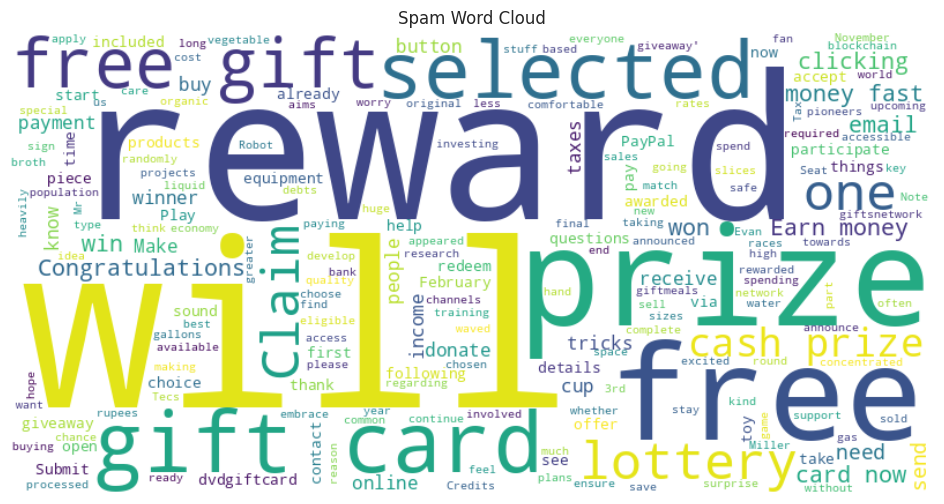

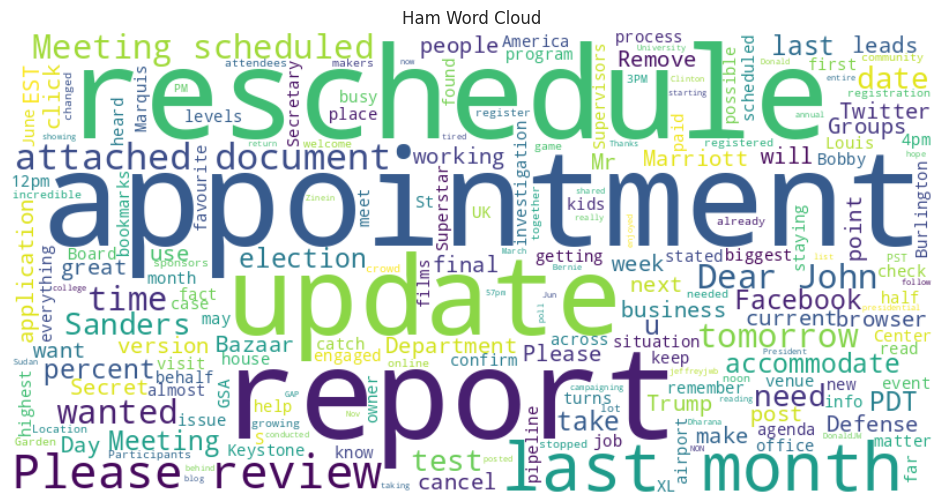

In [16]:
# Spam word cloud
spam_text = " ".join(df[df['label']==1]['text'])
spam_wc = WordCloud(width=800, height=400, background_color='white').generate(spam_text)
plt.figure(figsize=(12,6))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Spam Word Cloud")
plt.show()

# Ham word cloud
ham_text = " ".join(df[df['label']==0]['text'])
ham_wc = WordCloud(width=800, height=400, background_color='white').generate(ham_text)
plt.figure(figsize=(12,6))
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Ham Word Cloud")
plt.show()


# DEPLOYMENT OF THE PROJECT

In [17]:
!pip install gradio --quiet


In [25]:
import gradio as gr
import joblib

from google.colab import files

uploaded = files.upload()
nb_model = joblib.load("spam_classifier_nb.pkl")

Saving spam_classifier_nb.pkl to spam_classifier_nb (1).pkl


In [26]:
from google.colab import files

uploaded = files.upload()
vectorizer = joblib.load("tfidf_vectorizer.pkl")

Saving tfidf_vectorizer.pkl to tfidf_vectorizer.pkl


In [27]:
def classify_email(text):
    """Classify input email text as Spam or Ham."""
    vec = vectorizer.transform([text])
    pred = nb_model.predict(vec)[0]
    return "🚨 Spam" if pred == 1 else "✅ Ham"

In [ ]:
demo = gr.Interface(
    fn=classify_email,
    inputs=gr.Textbox(lines=5, placeholder="Paste email text here..."),
    outputs="text",
    title="📧 Spam Email Classifier",
    description="Enter an email to check if it's Spam or Ham."
)

demo.launch(share=True)
